In [15]:
import numpy as np

In [16]:
dih = np.array([[1,2,3,4,5],[5,4,3,2,1]])
print(dih)
print(dih.shape)

[[1 2 3 4 5]
 [5 4 3 2 1]]
(2, 5)


In [2]:
import time

In [3]:
from pynput import mouse
from pynput.mouse import Button, Controller
time.sleep(5)
mouse = Controller()
mouse.position = (1120, 500)
print('Now we have moved it to {0}'.format(
    mouse.position))
import time

Now we have moved it to (1120, 500)


In [14]:
time.sleep(3)
mouse.position =(160, 0)
time.sleep(3)
mouse.position =(1120, 0)
time.sleep(3)
mouse.position =(1120, 720)
time.sleep(3)
mouse.position =(160, 720)




In [19]:
mouse.scroll(0,-2)

In [11]:

for i in range (5):
    cursor_current_x,cursor_current_y = mouse.position
    print(cursor_current_x)
    print(cursor_current_y)
    time.sleep(5)


363
390
1009
405
267
405
637
127
639
683


In [21]:
from pynput.keyboard import Key, Controller
import time

keyboard = Controller()
# Press and release space
keyboard.press(Key.space)
keyboard.release(Key.space)

time.sleep(3)
# Type two upper case As
keyboard.press('1')
keyboard.release('1')
with keyboard.pressed(Key.shift):
    keyboard.press('a')
    keyboard.release('a')

# Type 'Hello World' using the shortcut type method
keyboard.type('Hello World')

In [22]:
time.sleep(5)
keyboard.press('1')
time.sleep(0.25)
keyboard.release('1')


In [1]:
import cv2
from matplotlib import pyplot as plt


In [35]:
path = r"C:\Osu!Conda\images\Retry Screen 1.jpg"
fullscreen_image = cv2.imread(path)
gray_full_img = cv2.cvtColor(fullscreen_image, cv2.COLOR_BGR2GRAY)

stamp_path = r"C:\Osu!Conda\images\Retry Screen 1 - Stamp.jpg"
stamp = cv2.imread(stamp_path)
stamp_gray = cv2.cvtColor(stamp, cv2.COLOR_BGR2GRAY)

height, width = stamp_gray.shape[:2]

# 3. Calculate the halfway point
half_height = height // 2 - 85

# 4. Slice the image into top and bottom parts
# Top half: from row 0 to half_height, all columns
top_half = stamp_gray[45:half_height, 95:130]
# Bottom half: from row half_height to the end, all columns


cv2.imshow("Top Half", top_half)
cv2.waitKey(0) # Display until a key is pressed
cv2.destroyAllWindows()
cv2.imwrite("top_half_cv.jpg", top_half)


similarity_map = cv2.matchTemplate(gray_full_img, top_half, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(similarity_map)
top_left_corner = max_loc
print(f"Match confidence score: {max_val}")

Match confidence score: 0.9690080285072327


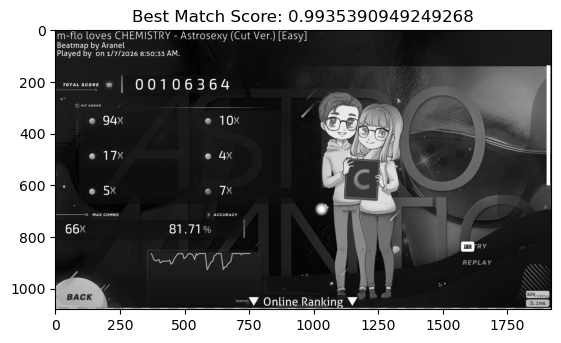

In [25]:
# Get the size of the stamp to know how big to draw the box
stamp_height, stamp_width = stamp_gray.shape

#calculating the bottom right corner for cv to use to make the rectangle
bottom_right_corner = (top_left_corner[0] + stamp_width, top_left_corner[1] + stamp_height)

# drawing a white rectangle on the grayscale image (just for viewing purposes)
# (the image i wanna use, x coordinate, y coordinate, color, border thickness)
cv2.rectangle(gray_full_img, top_left_corner, bottom_right_corner, 255, 10)

# View w matplotlib
plt.imshow(gray_full_img, cmap='gray')
plt.title(f"Best Match Score: {max_val}")
plt.show()

In [ ]:
time.sleep(5)
mouse.position = (1084,554)
mouse.click

#1280, 720

In [38]:
path = "C:\Osu!Conda\images\Retry Screen 2.jpg"
fullscreen_image = cv2.imread(path)
gray_full_img = cv2.cvtColor(fullscreen_image, cv2.COLOR_BGR2GRAY)

stamp_path = "C:\Osu!Conda\images\Retry Screen 2 - Stamp.jpg"
stamp = cv2.imread(stamp_path)
h, w = stamp.shape[:2]

# 3. Calculate the halfway point
half_height2 = h // 2 - 57

# 4. Slice the image into top and bottom parts
# Top half: from row 0 to half_height, all columns
top_half2 = stamp[1:half_height2,:40]
# Bottom half: from row half_height to the end, all columns


cv2.imshow("Top Half", top_half2)
cv2.waitKey(0) # Display until a key is pressed
cv2.destroyAllWindows()
cv2.imwrite("top_half_cv.jpg", top_half2)



stamp_gray = cv2.cvtColor(top_half2, cv2.COLOR_BGR2GRAY)

similarity_map = cv2.matchTemplate(gray_full_img, stamp_gray, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(similarity_map)
top_left_corner = max_loc
print(f"Match confidence score: {max_val}")

Match confidence score: 0.9931498169898987


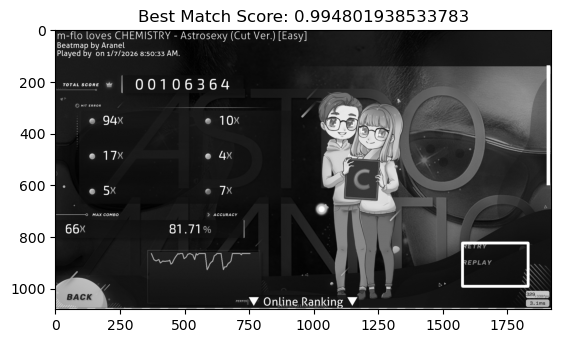

In [28]:
# Get the size of the stamp to know how big to draw the box
stamp_height, stamp_width = stamp_gray.shape

#calculating the bottom right corner for cv to use to make the rectangle
bottom_right_corner = (top_left_corner[0] + stamp_width, top_left_corner[1] + stamp_height)

# drawing a white rectangle on the grayscale image (just for viewing purposes)
# (the image i wanna use, x coordinate, y coordinate, color, border thickness)
cv2.rectangle(gray_full_img, top_left_corner, bottom_right_corner, 255, 10)

# View w matplotlib
plt.imshow(gray_full_img, cmap='gray')
plt.title(f"Best Match Score: {max_val}")
plt.show()

In [1]:
import cv2
import numpy as np
import time

# Generate fake 84x84 frame with some blobs
frame = np.random.randint(0, 50, (84, 84), dtype=np.uint8)
frame[20:30, 20:30] = 255  # Bright blob
frame[50:60, 50:60] = 255  # Another bright blob

# Test SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 10
params.maxArea = 500
detector = cv2.SimpleBlobDetector_create(params)

# Benchmark
times = []
for _ in range(1000):
    start = time.perf_counter()
    keypoints = detector.detect(frame)
    times.append(time.perf_counter() - start)

print(f"SimpleBlobDetector avg: {np.mean(times)*1000:.2f}ms")

# Test ConnectedComponents
times = []
for _ in range(1000):
    start = time.perf_counter()
    _, labels, stats, centroids = cv2.connectedComponentsWithStats(
        (frame > 200).astype(np.uint8)
    )
    times.append(time.perf_counter() - start)

print(f"ConnectedComponents avg: {np.mean(times)*1000:.2f}ms")

SimpleBlobDetector avg: 0.09ms
ConnectedComponents avg: 0.06ms


In [1]:
import requests
import time

In [ ]:
start_time=time.perf_counter()
for i in range (1):
    data = requests.get("http://localhost:24050/json/v2").json() 
    print(data)
end_time = time.perf_counter()

print(end_time-start_time)

{'game': {'focused': False, 'paused': True}, 'client': 'stable', 'server': 'ppy.sh', 'state': {'number': 2, 'name': 'play'}, 'session': {'playTime': 258886, 'playCount': 0}, 'settings': {'interfaceVisible': True, 'replayUIVisible': True, 'chatVisibilityStatus': {'number': 0, 'name': 'hidden'}, 'leaderboard': {'visible': False, 'type': {'number': 0, 'name': 'local'}}, 'progressBar': {'number': 1, 'name': 'pie'}, 'bassDensity': 3.3499999999999996, 'resolution': {'fullscreen': True, 'width': 1920, 'height': 1080, 'widthFullscreen': 1920, 'heightFullscreen': 1080}, 'client': {'updateAvailable': False, 'branch': 1, 'version': 'b20260101.1'}, 'scoreMeter': {'type': {'number': 2, 'name': 'error'}, 'size': 1.34}, 'cursor': {'useSkinCursor': True, 'autoSize': False, 'size': 0.85, 'menuSize': 0}, 'mouse': {'rawInput': False, 'disableButtons': False, 'disableWheel': False, 'sensitivity': 1}, 'tablet': {'enabled': False, 'x': 0, 'y': 0, 'width': 0, 'height': 0, 'rotation': 0, 'pressureThreshold': 